In [1]:
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import find_peaks

In [2]:
H5_FILE = Path("/home/mohamed-elarabie/BloodSensor/data/malaria_1dpc_2022_sensor_1.h5")

STAGE_NAMES = {
    0: "Normal",
    1: "Ring",
    2: "Trophozoite",
    3: "Schizont",
}

STAGE_IDS = list(STAGE_NAMES.keys())

print(f"Dataset: {H5_FILE}")
print(f"Exists:  {H5_FILE.exists()}")

Dataset: /home/mohamed-elarabie/BloodSensor/data/malaria_1dpc_2022_sensor_1.h5
Exists:  True


In [3]:
with h5py.File(H5_FILE, "r") as h5_file:

    wavelengths = h5_file["wavelengths"][:]
    reflectance = h5_file["Reflectance"][:]
    transmittance = h5_file["Transmittance"][:]
    ri = h5_file["RI"][:]
    labels = h5_file["labels"][:]

    metadata = dict(h5_file.attrs)


print("Dataset loaded successfully.")

print("\nShapes:")
print(f"Wavelengths:    {wavelengths.shape}")
print(f"Reflectance:    {reflectance.shape}")
print(f"Transmittance:  {transmittance.shape}")
print(f"RI:             {ri.shape}")
print(f"Labels:         {labels.shape}")

Dataset loaded successfully.

Shapes:
Wavelengths:    (2002,)
Reflectance:    (4000, 2002)
Transmittance:  (4000, 2002)
RI:             (4000, 2002)
Labels:         (4000,)


In [4]:
print("HDF5 metadata")
print("=" * 50)

for key, value in metadata.items():
    print(f"{key}: {value}")

HDF5 metadata
angle_deg: 86.0
defect_thickness_nm: 7000.0
metal: Ag
metal_thickness_nm: 15.0
mode: TM
reference_wavelength_nm: 800.0
sensor: (Si/SiO2)^3/Ag/Defect/Ag/(Si/SiO2)^3
si_periods: 3


In [5]:
class_counts = pd.Series(labels).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "class_id": class_counts.index,
    "class_name": [
        STAGE_NAMES[class_id]
        for class_id in class_counts.index
    ],
    "count": class_counts.values,
})

class_distribution

,class_id,class_name,count
0,0,Normal,1000
1,1,Ring,1000
2,2,Trophozoite,1000
3,3,Schizont,1000


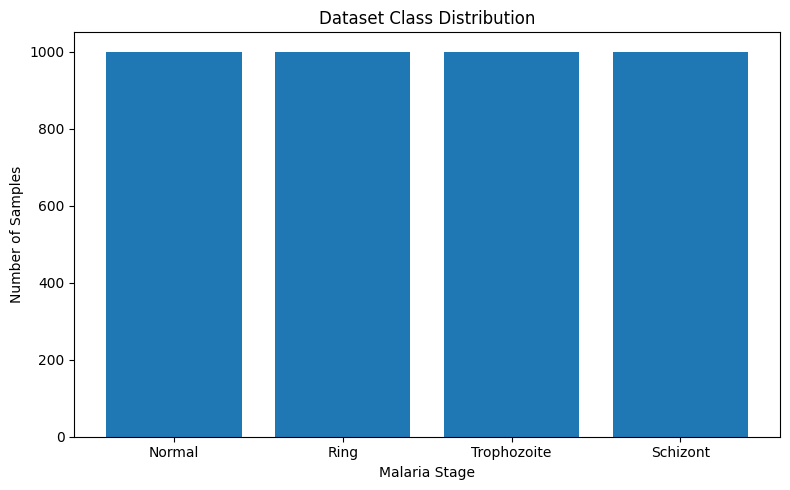

In [6]:
plt.figure(figsize=(8, 5))

plt.bar(
    class_distribution["class_name"],
    class_distribution["count"],
)

plt.xlabel("Malaria Stage")
plt.ylabel("Number of Samples")
plt.title("Dataset Class Distribution")
plt.tight_layout()
plt.show()

In [7]:
ri_statistics = []

for class_id, class_name in STAGE_NAMES.items():

    indices = np.where(labels == class_id)[0]

    stage_ri = ri[indices]

    ri_statistics.append({
        "class_id": class_id,
        "stage": class_name,
        "RI_min": np.min(stage_ri),
        "RI_max": np.max(stage_ri),
        "RI_mean": np.mean(stage_ri),
        "RI_std": np.std(stage_ri),
    })

ri_df = pd.DataFrame(ri_statistics)

ri_df

,class_id,stage,RI_min,RI_max,RI_mean,RI_std
0,0,Normal,1.369367,1.372538,1.370776,0.00091
1,1,Ring,1.366360,1.369531,1.367769,0.00091
2,2,Trophozoite,1.361185,1.364356,1.362594,0.00091
3,3,Schizont,1.356854,1.360024,1.358263,0.00091


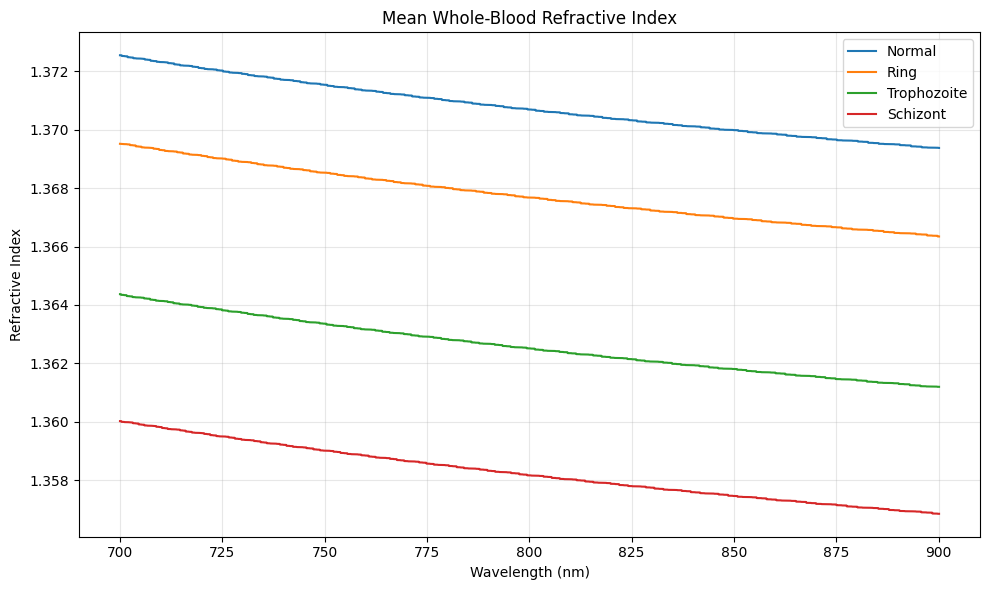

In [8]:
plt.figure(figsize=(10, 6))

for class_id, class_name in STAGE_NAMES.items():

    indices = np.where(labels == class_id)[0]

    mean_ri = np.mean(
        ri[indices],
        axis=0,
    )

    plt.plot(
        wavelengths,
        mean_ri,
        label=class_name,
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Refractive Index")
plt.title("Mean Whole-Blood Refractive Index")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
mean_transmission = {}

for class_id, class_name in STAGE_NAMES.items():

    indices = np.where(labels == class_id)[0]

    mean_transmission[class_id] = np.mean(
        transmittance[indices],
        axis=0,
    )

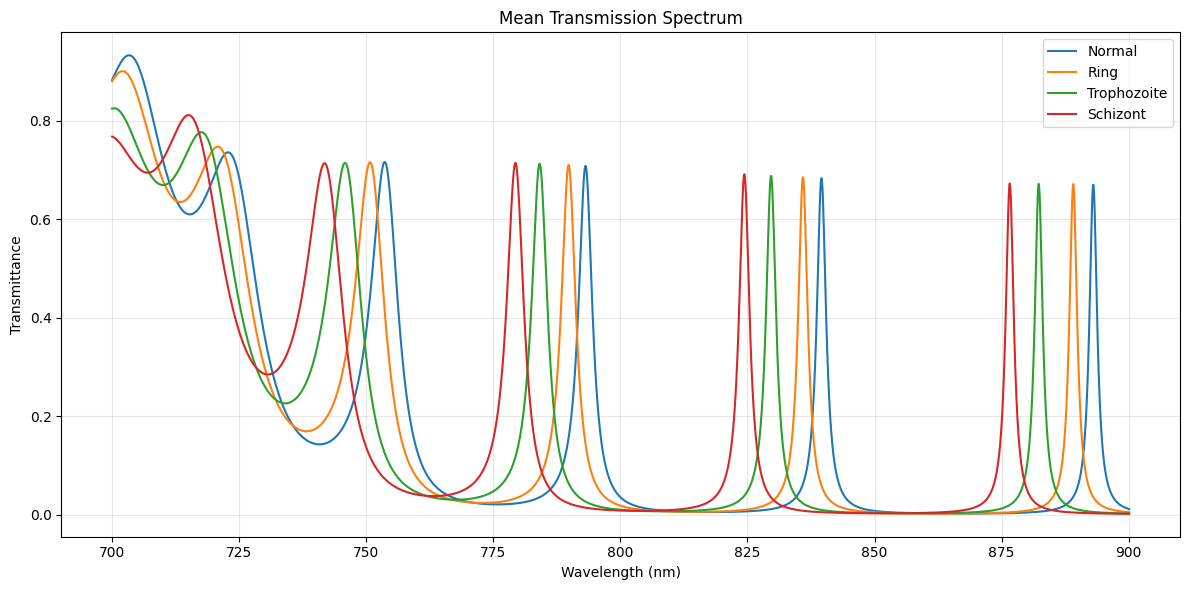

In [10]:
plt.figure(figsize=(12, 6))

for class_id, class_name in STAGE_NAMES.items():

    plt.plot(
        wavelengths,
        mean_transmission[class_id],
        label=class_name,
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmittance")
plt.title("Mean Transmission Spectrum")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
mean_reflectance = {}

for class_id, class_name in STAGE_NAMES.items():

    indices = np.where(labels == class_id)[0]

    mean_reflectance[class_id] = np.mean(
        reflectance[indices],
        axis=0,
    )

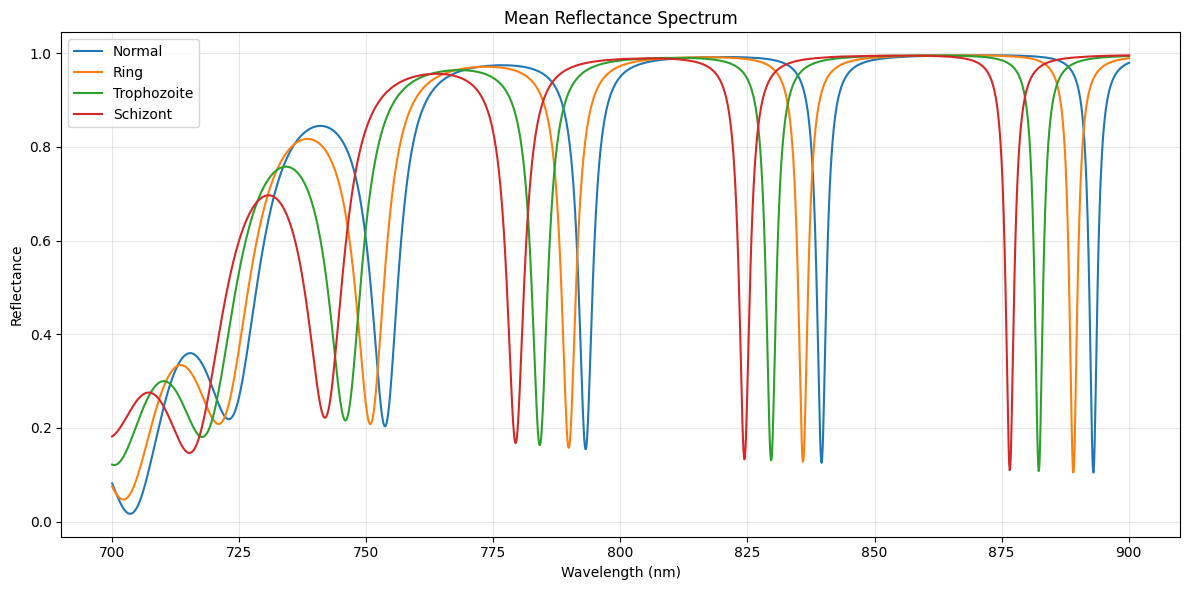

In [12]:
plt.figure(figsize=(12, 6))

for class_id, class_name in STAGE_NAMES.items():

    plt.plot(
        wavelengths,
        mean_reflectance[class_id],
        label=class_name,
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Mean Reflectance Spectrum")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
absorption = 1.0 - reflectance - transmittance

total_energy = (
    reflectance
    + transmittance
    + absorption
)

print("Energy conservation")
print("=" * 50)

print(f"Minimum R: {reflectance.min():.8f}")
print(f"Minimum T: {transmittance.min():.8f}")
print(f"Minimum A: {absorption.min():.8f}")

print(f"\nMaximum absorption: {absorption.max():.8f}")

print(
    f"\nMinimum R + T + A: "
    f"{total_energy.min():.8f}"
)

print(
    f"Maximum R + T + A: "
    f"{total_energy.max():.8f}"
)

print(
    f"Maximum numerical error: "
    f"{np.max(np.abs(total_energy - 1)):.2e}"
)


Energy conservation
Minimum R: 0.01673889
Minimum T: 0.00177068
Minimum A: 0.00163306

Maximum absorption: 0.22603375

Minimum R + T + A: 0.99999994
Maximum R + T + A: 1.00000000
Maximum numerical error: 5.96e-08


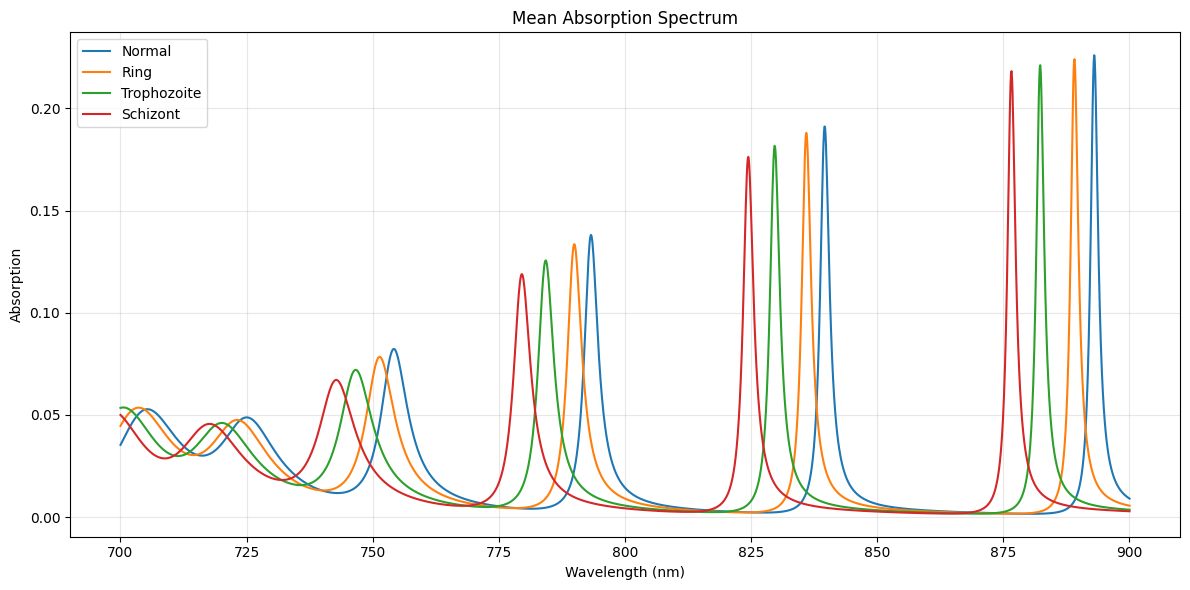

In [14]:
plt.figure(figsize=(12, 6))

for class_id, class_name in STAGE_NAMES.items():

    indices = np.where(labels == class_id)[0]

    mean_absorption = np.mean(
        absorption[indices],
        axis=0,
    )

    plt.plot(
        wavelengths,
        mean_absorption,
        label=class_name,
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorption")
plt.title("Mean Absorption Spectrum")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
def find_transmission_peaks(
    spectrum,
    wavelengths,
    prominence=0.01,
    distance=10,
):
    """
    Detect local transmission maxima.
    """

    peak_indices, properties = find_peaks(
        spectrum,
        prominence=prominence,
        distance=distance,
    )

    return (
        peak_indices,
        properties,
    )

In [16]:
all_peaks = {}

for class_id, class_name in STAGE_NAMES.items():

    spectrum = mean_transmission[class_id]

    peak_indices, properties = find_transmission_peaks(
        spectrum,
        wavelengths,
        prominence=0.01,
        distance=10,
    )

    all_peaks[class_id] = peak_indices

    print(f"\n{class_name}")
    print("-" * 50)

    for index in peak_indices:

        print(
            f"{wavelengths[index]:.2f} nm   "
            f"T = {spectrum[index]:.4f}"
        )


Normal
--------------------------------------------------
703.30 nm   T = 0.9332
722.80 nm   T = 0.7361
753.60 nm   T = 0.7164
793.10 nm   T = 0.7084
839.60 nm   T = 0.6833
893.00 nm   T = 0.6701

Ring
--------------------------------------------------
702.00 nm   T = 0.9009
720.80 nm   T = 0.7477
750.70 nm   T = 0.7157
789.80 nm   T = 0.7103
835.90 nm   T = 0.6855
889.10 nm   T = 0.6716

Trophozoite
--------------------------------------------------
717.50 nm   T = 0.7769
745.80 nm   T = 0.7146
784.10 nm   T = 0.7129
829.60 nm   T = 0.6879
882.30 nm   T = 0.6720

Schizont
--------------------------------------------------
715.00 nm   T = 0.8116
741.80 nm   T = 0.7138
779.30 nm   T = 0.7143
824.40 nm   T = 0.6916
876.60 nm   T = 0.6727


In [17]:
WAVELENGTH_MIN = 700
WAVELENGTH_MAX = 900

region_mask = (
    (wavelengths >= WAVELENGTH_MIN)
    & (wavelengths <= WAVELENGTH_MAX)
)

region_wavelengths = wavelengths[region_mask]

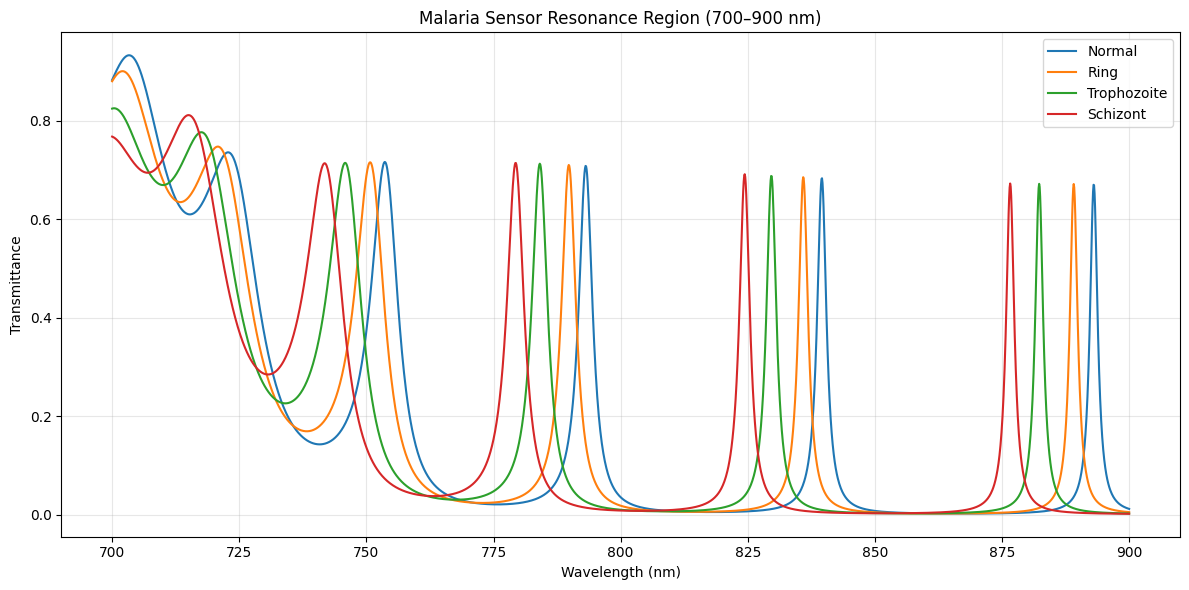

In [18]:
plt.figure(figsize=(12, 6))

for class_id, class_name in STAGE_NAMES.items():

    spectrum = mean_transmission[class_id]

    plt.plot(
        region_wavelengths,
        spectrum[region_mask],
        label=class_name,
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Transmittance")
plt.title(
    "Malaria Sensor Resonance Region "
    f"({WAVELENGTH_MIN}–{WAVELENGTH_MAX} nm)"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
TARGET_RESONANCE = 793.0
SEARCH_WINDOW = 25.0

In [20]:
def track_resonance(
    class_id,
    target_wavelength,
    search_window=25.0,
):
    """
    Find the transmission resonance closest to
    the target wavelength.
    """

    spectrum = mean_transmission[class_id]

    peak_indices, _ = find_transmission_peaks(
        spectrum,
        wavelengths,
        prominence=0.01,
        distance=10,
    )

    peak_wavelengths = wavelengths[peak_indices]

    mask = (
        np.abs(
            peak_wavelengths - target_wavelength
        )
        <= search_window
    )

    candidate_indices = peak_indices[mask]

    if len(candidate_indices) == 0:
        return None

    best_index = candidate_indices[
        np.argmin(
            np.abs(
                wavelengths[candidate_indices]
                - target_wavelength
            )
        )
    ]

    return int(best_index)

In [21]:
resonance_results = []

for class_id, class_name in STAGE_NAMES.items():

    index = track_resonance(
        class_id,
        TARGET_RESONANCE,
        SEARCH_WINDOW,
    )

    if index is None:
        print(
            f"No resonance found for {class_name}"
        )
        continue

    stage_ri = np.mean(
        ri[
            labels == class_id,
            index,
        ]
    )

    resonance_results.append({
        "class_id": class_id,
        "stage": class_name,
        "wavelength_nm": wavelengths[index],
        "transmission": mean_transmission[
            class_id
        ][index],
        "RI": stage_ri,
    })

resonance_df = pd.DataFrame(
resonance_results
)

resonance_df

,class_id,stage,wavelength_nm,transmission,RI
0,0,Normal,793.1,0.708391,1.370798
1,1,Ring,789.8,0.710344,1.367844
2,2,Trophozoite,784.1,0.712912,1.362761
3,3,Schizont,779.3,0.714338,1.358507


In [22]:
normal_row = resonance_df[
    resonance_df["class_id"] == 0
].iloc[0]

normal_wavelength = (
    normal_row["wavelength_nm"]
)

normal_ri = normal_row["RI"]

sensitivity_results = []

for _, row in resonance_df.iterrows():

    if row["class_id"] == 0:
        continue

    delta_lambda = (
        row["wavelength_nm"]
        - normal_wavelength
    )

    delta_ri = (
        row["RI"]
        - normal_ri
    )

    sensitivity = (
        abs(delta_lambda)
        / abs(delta_ri)
    )

    sensitivity_results.append({
        "stage": row["stage"],
        "normal_wavelength_nm": normal_wavelength,
        "stage_wavelength_nm": row[
            "wavelength_nm"
        ],
        "delta_lambda_nm": delta_lambda,
        "normal_ri": normal_ri,
        "stage_ri": row["RI"],
        "delta_ri": delta_ri,
        "sensitivity_nm_per_RIU": sensitivity,
    })

sensitivity_df = pd.DataFrame(
    sensitivity_results
)

sensitivity_df

,stage,normal_wavelength_nm,stage_wavelength_nm,delta_lambda_nm,normal_ri,stage_ri,delta_ri,sensitivity_nm_per_RIU
0,Ring,793.1,789.8,-3.3,1.370798,1.367844,-0.002955,1116.901610
1,Trophozoite,793.1,784.1,-9.0,1.370798,1.362761,-0.008038,1119.741813
2,Schizont,793.1,779.3,-13.8,1.370798,1.358507,-0.012291,1122.798689


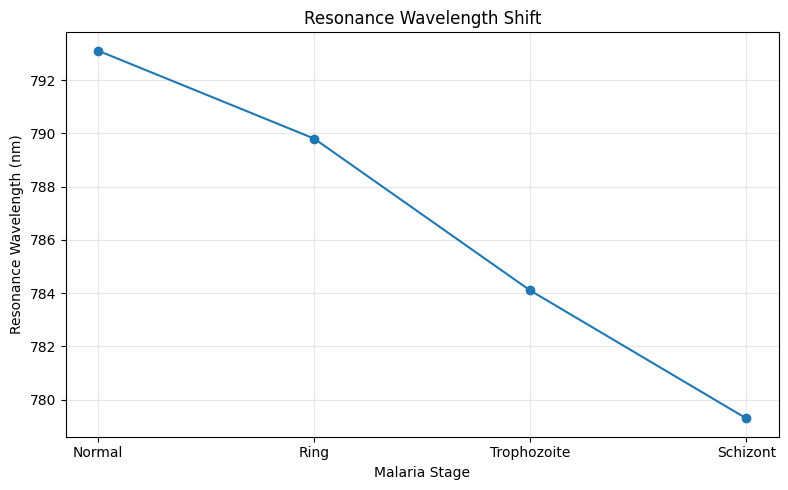

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    resonance_df["stage"],
    resonance_df["wavelength_nm"],
    marker="o",
)

plt.xlabel("Malaria Stage")
plt.ylabel("Resonance Wavelength (nm)")
plt.title("Resonance Wavelength Shift")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

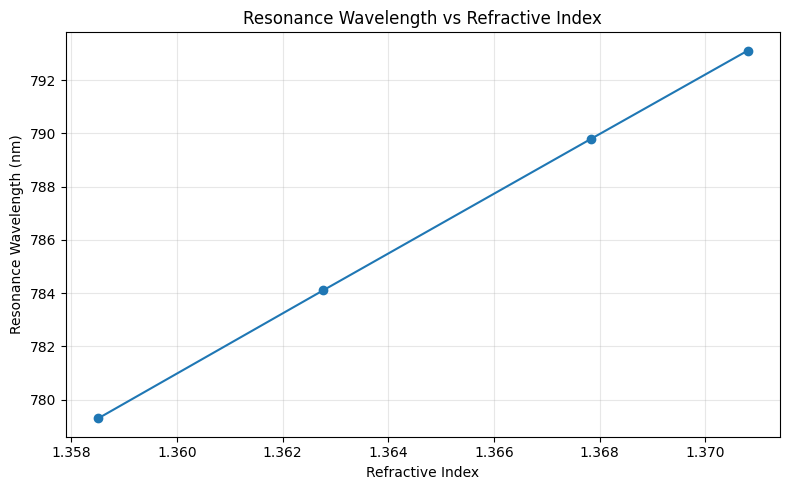

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    resonance_df["RI"],
    resonance_df["wavelength_nm"],
    marker="o",
)

plt.xlabel("Refractive Index")
plt.ylabel("Resonance Wavelength (nm)")
plt.title("Resonance Wavelength vs Refractive Index")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
resonance_df.to_csv(
    "resonance_analysis_sensor_1.csv",
    index=False,
)

sensitivity_df.to_csv(
    "sensitivity_analysis_sensor_1.csv",
    index=False,
)

print("Analysis files saved:")
print("  resonance_analysis_sensor_1.csv")
print("  sensitivity_analysis_sensor_1.csv")

Analysis files saved:
  resonance_analysis_sensor_1.csv
  sensitivity_analysis_sensor_1.csv
